# 07b - PatchTST Walk-Forward Classification

- Dataset: `daily_stock_optimal_bucket_modeling_with_fred.parquet` (same as 07_PatchTSTfor_Classification)
- Target: 7-class `optimal_bucket` (with merged OTM buckets, same mapping as 07)
- Walk-forward validation, annual retraining (following 07_lstm_model_copy strategy)
- Per-fold: RF feature selection (top 35) → StandardScaler → sequence build → class balance → PatchTST train
- 50-day lookback sequences with context window at fold boundaries
- Evaluation: per-year accuracy / macro F1, classification report, confusion matrix

## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import PatchTSTConfig, PatchTSTForClassification

plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = Path('../data/clean/daily_stock_optimal_bucket_modeling_with_fred.parquet')
MODELS_DIR = Path('../saved_models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else 'cpu')

SEED        = 42
SEQ_LEN     = 50   # same as 07_PatchTSTfor_Classification
TOP_N_FEAT  = 35   # RF feature selection top-N
FIRST_TEST  = 2015 # first walk-forward test year

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Device : {device}')
print(f'Seq len: {SEQ_LEN}, Top features: {TOP_N_FEAT}, First test year: {FIRST_TEST}')

Device : mps
Seq len: 50, Top features: 35, First test year: 2015


## 2. Load Data & Apply Bucket Mapping

In [2]:
df = pd.read_parquet(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print('Raw shape:', df.shape)
print('Date range:', df['date'].min().date(), '–', df['date'].max().date())
print('Symbols:', sorted(df['symbol'].unique()))
print('\nOriginal bucket distribution:')
print(df['optimal_bucket'].value_counts())

Raw shape: (41266, 88)
Date range: 2006-01-03 – 2024-12-31
Symbols: ['AAPL', 'AMZN', 'AVGO', 'GOOG', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA', 'WMT']

Original bucket distribution:
optimal_bucket
ATM_90      15324
ATM_60       6470
ATM_30       4893
OTM5_30      3813
OTM10_30     3463
OTM5_60      2602
OTM10_90     2580
OTM5_90      1367
OTM10_60      754
Name: count, dtype: int64


In [3]:
# Merge bucket labels exactly as in 07_PatchTSTfor_Classification
bucket_map = {
    'OTM10_60': 'OTM10_60_90',
    'OTM10_90': 'OTM10_60_90',
    'OTM5_60' : 'OTM5_60_90',
    'OTM5_90' : 'OTM5_60_90',
}
df['optimal_bucket'] = df['optimal_bucket'].replace(bucket_map)

print('Updated bucket distribution:')
print(df['optimal_bucket'].value_counts())

# Fit a global LabelEncoder so class indices are stable across folds
global_le = LabelEncoder()
global_le.fit(sorted(df['optimal_bucket'].unique()))
df['target'] = global_le.transform(df['optimal_bucket'])

NUM_CLASSES = len(global_le.classes_)
print(f'\nClasses ({NUM_CLASSES}):', dict(zip(global_le.classes_,
                                              global_le.transform(global_le.classes_))))

df['year'] = df['date'].dt.year

Updated bucket distribution:
optimal_bucket
ATM_90         15324
ATM_60          6470
ATM_30          4893
OTM5_60_90      3969
OTM5_30         3813
OTM10_30        3463
OTM10_60_90     3334
Name: count, dtype: int64

Classes (7): {np.str_('ATM_30'): np.int64(0), np.str_('ATM_60'): np.int64(1), np.str_('ATM_90'): np.int64(2), np.str_('OTM10_30'): np.int64(3), np.str_('OTM10_60_90'): np.int64(4), np.str_('OTM5_30'): np.int64(5), np.str_('OTM5_60_90'): np.int64(6)}


## 3. Helper Functions

In [4]:
# ── Column helpers ────────────────────────────────────────────────────────────
EXCLUDE_ALWAYS = {'symbol', 'date', 'fiscalDateEnding', 'optimal_bucket', 'target', 'year'}

def get_candidate_features(df_subset):
    """Return numeric columns that are not ID/target fields."""
    return [
        c for c in df_subset.select_dtypes(include='number').columns
        if c not in EXCLUDE_ALWAYS
    ]


# ── RF feature selection (fit on train split only) ───────────────────────────
def select_features_rf(train_df, top_n=TOP_N_FEAT, seed=SEED):
    """Fit a fast RF on the training data and return top-N feature names."""
    candidate_cols = get_candidate_features(train_df)
    X = train_df[candidate_cols].fillna(0).values
    y = train_df['target'].values

    rf = RandomForestClassifier(
        n_estimators=100, max_depth=10,
        n_jobs=-1, random_state=seed,
        class_weight='balanced_subsample'
    )
    rf.fit(X, y)

    importances = pd.Series(rf.feature_importances_, index=candidate_cols)
    return importances.nlargest(top_n).index.tolist()


# ── Sequence builders (mirror of lstm_model_copy strategy) ───────────────────
def build_sequences(panel_df, feature_cols, seq_len=SEQ_LEN):
    """Sliding-window sequences from a single time-period partition."""
    X_list, y_list, date_list = [], [], []
    for sym, grp in panel_df.groupby('symbol'):
        grp = grp.sort_values('date').reset_index(drop=True)
        feats  = grp[feature_cols].values
        labels = grp['target'].values
        dates  = grp['date'].values
        if len(grp) < seq_len:
            continue
        for i in range(seq_len, len(grp)):
            X_list.append(feats[i - seq_len:i])
            y_list.append(labels[i])
            date_list.append(dates[i])
    if not X_list:
        return (np.empty((0, seq_len, len(feature_cols))),
                np.array([]), np.array([]))
    return np.array(X_list, dtype=np.float32), np.array(y_list), np.array(date_list)


def build_sequences_with_context(target_df, context_df, feature_cols, seq_len=SEQ_LEN):
    """Prepend tail of context so first rows of target get a full lookback."""
    X_list, y_list, date_list = [], [], []
    for sym in target_df['symbol'].unique():
        ctx = (context_df[context_df['symbol'] == sym]
               .sort_values('date').tail(seq_len))
        tgt = target_df[target_df['symbol'] == sym].sort_values('date')
        combined = pd.concat([ctx, tgt]).sort_values('date').reset_index(drop=True)
        feats  = combined[feature_cols].values
        labels = combined['target'].values
        dates  = combined['date'].values
        ctx_len = len(ctx)
        for i in range(max(seq_len, ctx_len), len(combined)):
            X_list.append(feats[i - seq_len:i])
            y_list.append(labels[i])
            date_list.append(dates[i])
    if not X_list:
        return (np.empty((0, seq_len, len(feature_cols))),
                np.array([]), np.array([]))
    return np.array(X_list, dtype=np.float32), np.array(y_list), np.array(date_list)


# ── Class balancing ───────────────────────────────────────────────────────────
def balance_sequences(X, y, seed=SEED):
    """
    Proportional resampling: each class is resampled to the median class count.
    Over-represented classes are downsampled; under-represented are oversampled.
    """
    rng = np.random.RandomState(seed)
    classes, counts = np.unique(y, return_counts=True)
    median_count = int(np.median(counts))
    indices = []
    for cls in classes:
        idx = np.where(y == cls)[0]
        if len(idx) >= median_count:
            chosen = rng.choice(idx, size=median_count, replace=False)
        else:
            chosen = rng.choice(idx, size=median_count, replace=True)
        indices.extend(chosen.tolist())
    indices = np.array(indices)
    return X[indices], y[indices]


print('Helper functions defined.')

Helper functions defined.


## 4. PyTorch Dataset

In [5]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {'past_values': self.X[idx], 'target': self.y[idx]}

print('TimeSeriesDataset defined.')

TimeSeriesDataset defined.


## 5. PatchTST Model Builder

In [6]:
def build_patchtst(num_input_channels, num_classes,
                   context_length=SEQ_LEN,
                   patch_length=5, stride=5,
                   d_model=128, num_attention_heads=4,
                   num_hidden_layers=3, ffn_dim=256,
                   dropout=0.1, head_dropout=0.1):
    config = PatchTSTConfig(
        num_input_channels=num_input_channels,
        context_length=context_length,
        patch_length=patch_length,
        stride=stride,
        num_targets=num_classes,
        d_model=d_model,
        num_attention_heads=num_attention_heads,
        num_hidden_layers=num_hidden_layers,
        ffn_dim=ffn_dim,
        dropout=dropout,
        head_dropout=head_dropout,
        norm_type='batchnorm'
    )
    return PatchTSTForClassification(config)


# Quick sanity-check
_m = build_patchtst(35, NUM_CLASSES)
n_params = sum(p.numel() for p in _m.parameters())
print(f'PatchTST params: {n_params:,} (35 features, {NUM_CLASSES} classes, d_model=128)')
del _m

PatchTST params: 435,463 (35 features, 7 classes, d_model=128)


## 6. Training & Evaluation Functions

In [7]:
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss, preds, targets = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            x = batch['past_values'].to(device)
            y = batch['target'].to(device)
            logits = model(past_values=x).prediction_logits
            total_loss += criterion(logits, y).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            targets.extend(y.cpu().numpy())
    macro_f1 = f1_score(targets, preds, average='macro', zero_division=0)
    return total_loss / len(loader), macro_f1, np.array(preds)


class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    """Linear warmup for `warmup_epochs`, then cosine decay to `min_lr`."""
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.min_lr        = min_lr
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        e = self.last_epoch
        if e < self.warmup_epochs:
            scale = (e + 1) / self.warmup_epochs
            return [base_lr * scale for base_lr in self.base_lrs]
        progress = (e - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
        cosine   = 0.5 * (1 + np.cos(np.pi * progress))
        return [self.min_lr + (base_lr - self.min_lr) * cosine
                for base_lr in self.base_lrs]


def train_patchtst_fold(X_train, y_train, X_val, y_val,
                        num_input_channels, num_classes,
                        class_weights,
                        lr=1e-4, weight_decay=1e-4,
                        epochs=60, patience=12,
                        warmup_epochs=5,
                        batch_size=64):
    """Train one walk-forward fold with LR warmup + cosine decay."""
    train_loader = DataLoader(
        TimeSeriesDataset(X_train, y_train),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TimeSeriesDataset(X_val, y_val),
        batch_size=128, shuffle=False
    )

    model = build_patchtst(
        num_input_channels=num_input_channels,
        num_classes=num_classes
    ).to(device)

    weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = WarmupCosineScheduler(optimizer,
                                      warmup_epochs=warmup_epochs,
                                      total_epochs=epochs)

    best_val_f1, best_state, wait = -1.0, None, 0
    history = {'train_loss': [], 'val_f1': [], 'lr': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            x = batch['past_values'].to(device)
            y = batch['target'].to(device)
            optimizer.zero_grad()
            logits = model(past_values=x).prediction_logits
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        history['train_loss'].append(epoch_loss / len(train_loader))
        history['lr'].append(scheduler.get_last_lr()[0])

        _, val_f1, _ = evaluate_model(model, val_loader, criterion, device)
        history['val_f1'].append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.to(device)
    return model, best_val_f1, history


print('Training functions defined.')
print('  lr=1e-4, warmup=5 epochs, epochs=60, patience=12, d_model=128')

Training functions defined.
  lr=1e-4, warmup=5 epochs, epochs=60, patience=12, d_model=128


## 7. Walk-Forward Validation Loop

In [8]:
test_years = [y for y in sorted(df['year'].unique()) if y >= FIRST_TEST]
print(f'Walk-forward test years: {test_years}\n')

all_preds, all_true, all_dates = [], [], []
fold_results = []
fold_histories = {}

for test_year in test_years:
    print(f"{'='*65}")
    print(f'Test year: {test_year}')

    # ── Data splits ──────────────────────────────────────────────
    train_data = df[df['year'] <  test_year].copy()
    test_data  = df[df['year'] == test_year].copy()

    if len(train_data) < 500:
        print(f'  Skipping: insufficient training data ({len(train_data)} rows)')
        continue

    val_year   = test_year - 1
    pure_train = train_data[train_data['year'] < val_year].copy()
    val_data   = train_data[train_data['year'] == val_year].copy()

    if len(pure_train) < 500:
        tr_sorted  = train_data.sort_values('date')
        split_idx  = int(len(tr_sorted) * 0.8)
        pure_train = tr_sorted.iloc[:split_idx].copy()
        val_data   = tr_sorted.iloc[split_idx:].copy()

    # ── Skip fold if test contains classes unseen in raw training ─
    missing_raw = set(test_data['target'].unique()) - set(pure_train['target'].unique())
    if missing_raw:
        names = [global_le.classes_[i] for i in sorted(missing_raw)]
        print(f'  Skipping: class(es) {names} not in training data.')
        continue

    # ── Feature selection on pure_train ──────────────────────────
    feature_cols = select_features_rf(pure_train, top_n=TOP_N_FEAT)
    print(f'  Features selected: {len(feature_cols)}')

    # Fill NaN before scaling
    for part in [pure_train, val_data, test_data]:
        part[feature_cols] = part[feature_cols].fillna(0)

    # ── StandardScaler fitted on pure_train ──────────────────────
    scaler = StandardScaler()
    pure_train = pure_train.copy()
    pure_train[feature_cols] = scaler.fit_transform(pure_train[feature_cols])
    val_data   = val_data.copy()
    val_data[feature_cols]   = scaler.transform(val_data[feature_cols])
    test_data  = test_data.copy()
    test_data[feature_cols]  = scaler.transform(test_data[feature_cols])

    # ── Build sequences ───────────────────────────────────────────
    X_train_raw, y_train_raw, _ = build_sequences(
        pure_train, feature_cols, SEQ_LEN)
    X_val, y_val, _ = build_sequences_with_context(
        val_data, pure_train, feature_cols, SEQ_LEN)
    X_test, y_test, dates_test = build_sequences_with_context(
        test_data, train_data, feature_cols, SEQ_LEN)

    if len(X_train_raw) == 0 or len(X_val) == 0 or len(X_test) == 0:
        print(f'  Skipping: empty sequences '
              f'(train={len(X_train_raw)}, val={len(X_val)}, test={len(X_test)})')
        continue

    # ── Second check: classes absent from sequences (not just raw) ─
    missing_seq = set(np.unique(y_test)) - set(np.unique(y_train_raw))
    if missing_seq:
        names = [global_le.classes_[i] for i in sorted(missing_seq)]
        print(f'  Skipping: class(es) {names} absent from training sequences '
              f'(too few consecutive rows in this period).')
        continue

    # ── Class balancing on train sequences ───────────────────────
    X_train_bal, y_train_bal = balance_sequences(X_train_raw, y_train_raw, seed=SEED)

    # ── Class weights for loss ────────────────────────────────────
    classes_present = np.sort(np.unique(y_train_bal))
    cw = compute_class_weight('balanced', classes=classes_present, y=y_train_bal)
    full_cw = np.ones(NUM_CLASSES, dtype=np.float32)
    for cls, w in zip(classes_present, cw):
        full_cw[cls] = w

    n_feat = X_train_bal.shape[2]
    print(f'  train={len(X_train_bal):,}, val={len(X_val):,}, test={len(X_test):,}')
    print(f'  Class dist (train_bal): '
          f'{dict(zip(*np.unique(y_train_bal, return_counts=True)))}')

    # ── Train PatchTST ────────────────────────────────────────────
    torch.manual_seed(SEED)
    model, val_f1, history = train_patchtst_fold(
        X_train_bal, y_train_bal, X_val, y_val,
        num_input_channels=n_feat,
        num_classes=NUM_CLASSES,
        class_weights=full_cw,
    )

    # ── Evaluate on test ──────────────────────────────────────────
    weights_tensor = torch.tensor(full_cw, dtype=torch.float32, device=device)
    criterion_eval = nn.CrossEntropyLoss(weight=weights_tensor)
    test_loader = DataLoader(
        TimeSeriesDataset(X_test, y_test),
        batch_size=128, shuffle=False
    )
    _, test_f1, preds = evaluate_model(model, test_loader, criterion_eval, device)
    test_acc = accuracy_score(y_test, preds)

    all_preds.extend(preds.tolist())
    all_true.extend(y_test.tolist())
    all_dates.extend(dates_test.tolist())
    fold_histories[test_year] = history

    fold_results.append(dict(
        year=test_year, n_feat=n_feat,
        train=len(X_train_bal), val=len(X_val), test=len(X_test),
        acc=test_acc, f1=test_f1, val_f1=val_f1,
        epochs=len(history['train_loss'])
    ))
    print(f'  Acc={test_acc:.4f}, F1={test_f1:.4f}  '
          f'(val_f1={val_f1:.4f}, epochs={len(history["train_loss"])})')

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

wf_acc = accuracy_score(all_true, all_preds)
wf_f1  = f1_score(all_true, all_preds, average='macro', zero_division=0)
print(f"\n{'='*65}")
print(f'Overall Walk-Forward PatchTST: Acc={wf_acc:.4f}, Macro F1={wf_f1:.4f}')

Walk-forward test years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]

Test year: 2015
  Skipping: class(es) [np.str_('OTM10_60_90')] not in training data.
Test year: 2016
  Features selected: 35
  train=19,752, val=2,465, test=2,520
  Class dist (train_bal): {np.int64(0): np.int64(3292), np.int64(1): np.int64(3292), np.int64(2): np.int64(3292), np.int64(3): np.int64(3292), np.int64(5): np.int64(3292), np.int64(6): np.int64(3292)}
  Acc=0.1409, F1=0.1520  (val_f1=0.1945, epochs=21)
Test year: 2017
  Features selected: 35
  train=21,336, val=2,520, test=2,510
  Class dist (train_bal): {np.int64(0): np.int64(3048), np.int64(1): np.int64(3048), np.int64(2): np.int64(3048), np.int64(3): np.int64(3048), np.int64(4): np.int64(3048), np.int64(5): np.int64(3048), np.int64(6): np.int64(3048)}
  Acc=0.3052, F1=0.1497  (val_f1=0.2254, epochs=18)
Test year: 2018
  Features selected: 

## 8. Per-Year Results Table

In [9]:
fold_df = pd.DataFrame(fold_results)
print('Per-Year Walk-Forward Results:')
print(fold_df[['year', 'train', 'val', 'test', 'acc', 'f1', 'val_f1', 'epochs']]
      .to_string(index=False))
print(f'\nMean Acc={fold_df["acc"].mean():.4f}, Mean F1={fold_df["f1"].mean():.4f}')

Per-Year Walk-Forward Results:
 year  train  val  test      acc       f1   val_f1  epochs
 2016  19752 2465  2520 0.140873 0.152000 0.194473      21
 2017  21336 2520  2510 0.305179 0.149668 0.225418      18
 2018  25396 2510  2510 0.164143 0.077318 0.159975      14
 2019  25396 2510  2520 0.143651 0.090772 0.206289      25
 2020  25396 2520  2530 0.517787 0.198932 0.232202      17
 2021  25396 2530  2520 0.280159 0.121156 0.353398      47
 2022  25396 2520  2510 0.221116 0.112972 0.264577      15
 2023  25396 2510  2500 0.221200 0.138247 0.171224      21
 2024  25557 2500  2520 0.275794 0.122604 0.191678      18

Mean Acc=0.2522, Mean F1=0.1293


## 9. Per-Year F1 Bar Chart

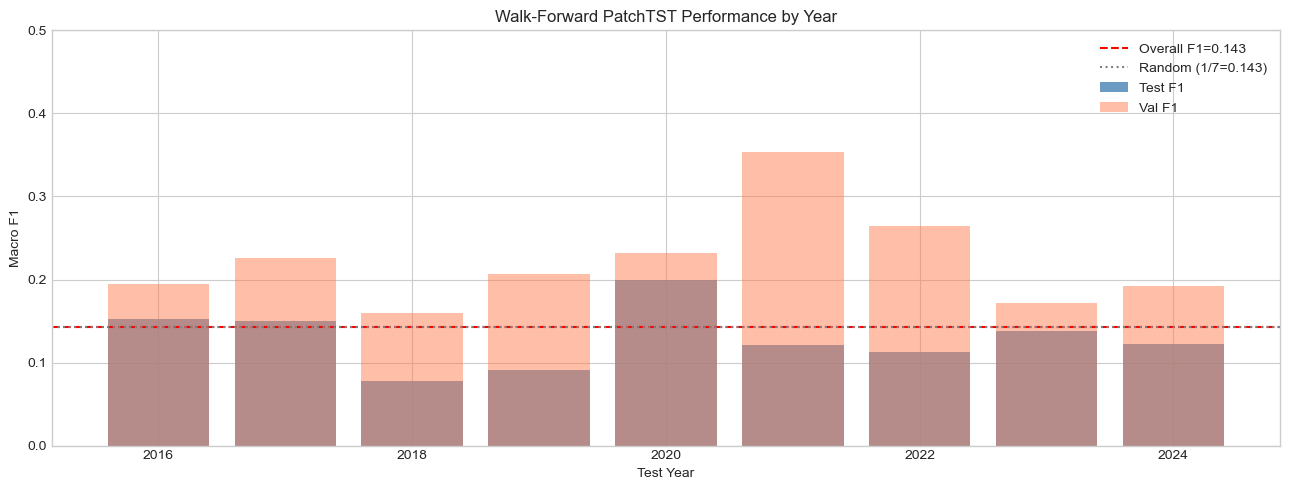

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(fold_df['year'], fold_df['f1'],  color='steelblue', alpha=0.8, label='Test F1')
ax.bar(fold_df['year'], fold_df['val_f1'], color='coral',  alpha=0.5, label='Val F1')
ax.axhline(wf_f1, color='red',  linestyle='--', label=f'Overall F1={wf_f1:.3f}')
ax.axhline(1/NUM_CLASSES, color='gray', linestyle=':', label=f'Random (1/{NUM_CLASSES}={1/NUM_CLASSES:.3f})')
ax.set_xlabel('Test Year')
ax.set_ylabel('Macro F1')
ax.set_title('Walk-Forward PatchTST Performance by Year')
ax.legend(loc='upper right')
ax.set_ylim(0, max(fold_df['f1'].max() * 1.2, 0.5))
plt.tight_layout()
plt.savefig('../reports/figures/patchtst_walkforward_yearly_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Classification Report

In [11]:
print('Overall Walk-Forward Classification Report:')
print(classification_report(
    all_true, all_preds,
    target_names=global_le.classes_,
    zero_division=0
))

Overall Walk-Forward Classification Report:
              precision    recall  f1-score   support

      ATM_30       0.04      0.06      0.05      1047
      ATM_60       0.06      0.13      0.08      2121
      ATM_90       0.66      0.28      0.39     12588
    OTM10_30       0.00      0.00      0.00       315
 OTM10_60_90       0.16      0.20      0.18      3291
     OTM5_30       0.00      0.00      0.00        85
  OTM5_60_90       0.24      0.37      0.29      3193

    accuracy                           0.25     22640
   macro avg       0.17      0.15      0.14     22640
weighted avg       0.43      0.25      0.30     22640



## 11. Confusion Matrix

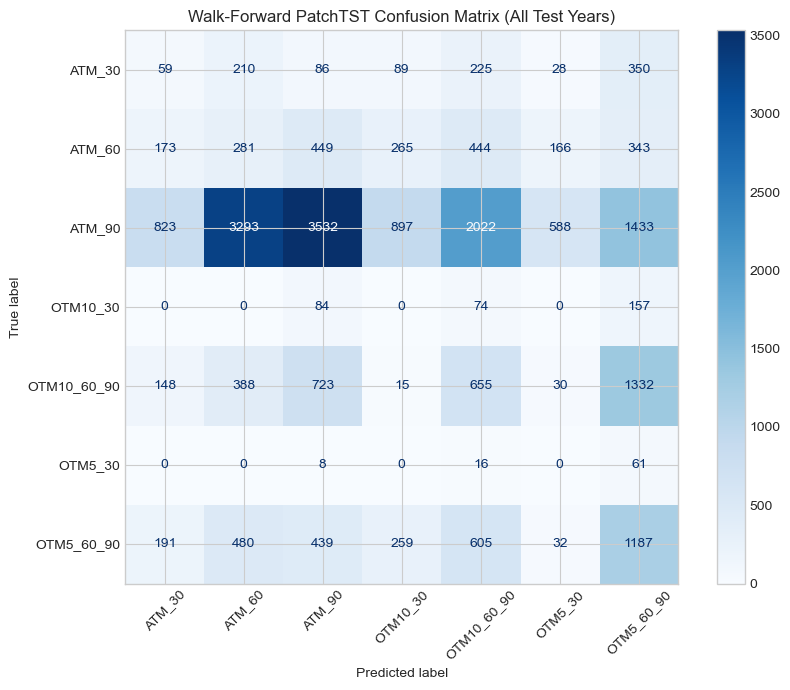

In [12]:
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=global_le.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=45)
ax.set_title('Walk-Forward PatchTST Confusion Matrix (All Test Years)')
plt.tight_layout()
plt.savefig('../reports/figures/patchtst_walkforward_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Training Curves (Sample Folds)

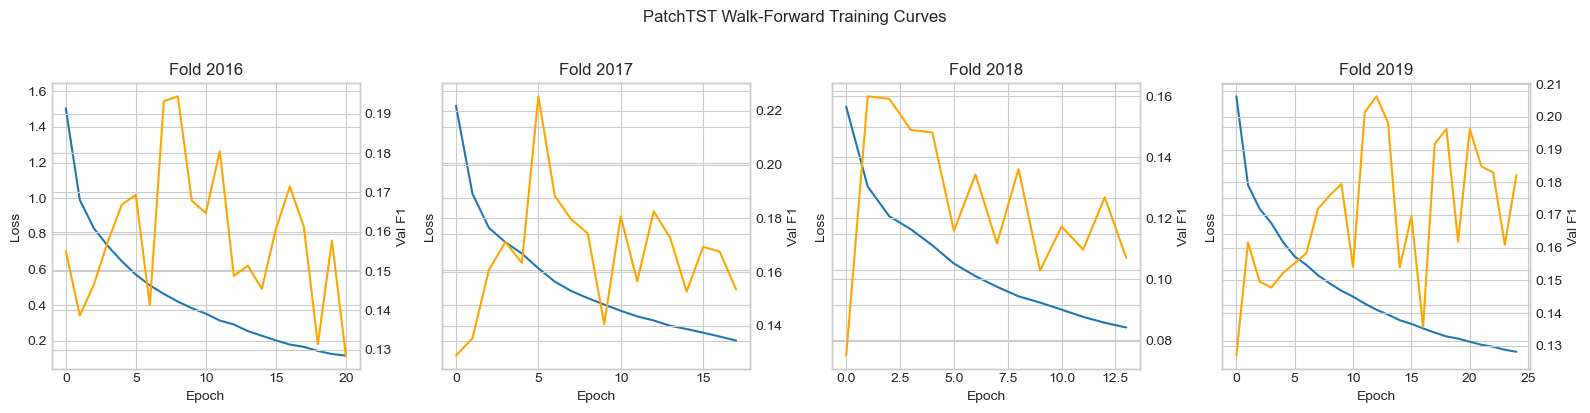

In [13]:
sample_years = list(fold_histories.keys())[:4]   # first 4 folds
fig, axes = plt.subplots(1, len(sample_years), figsize=(4 * len(sample_years), 4), sharey=True)
if len(sample_years) == 1:
    axes = [axes]
for ax, yr in zip(axes, sample_years):
    h = fold_histories[yr]
    ax.plot(h['train_loss'], label='Train Loss')
    ax2 = ax.twinx()
    ax2.plot(h['val_f1'], color='orange', label='Val F1')
    ax.set_title(f'Fold {yr}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax2.set_ylabel('Val F1')
fig.suptitle('PatchTST Walk-Forward Training Curves', y=1.02)
plt.tight_layout()
plt.show()

## 13. Save Results

In [14]:
RESULTS_DIR = Path('../data/processed')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fold_df.to_csv(RESULTS_DIR / 'patchtst_walkforward_results.csv', index=False)
print('Saved: patchtst_walkforward_results.csv')

# Append to all_model_results if it exists
row = pd.DataFrame([{
    'Model'   : 'PatchTST walk-forward (daily)',
    'Accuracy': round(wf_acc, 6),
    'Macro F1': round(wf_f1,  6)
}])
results_path = RESULTS_DIR / 'all_model_results.csv'
try:
    prev = pd.read_csv(results_path)
    prev = prev[~prev['Model'].str.contains('PatchTST walk-forward', case=False)]
    row = pd.concat([prev, row], ignore_index=True)
except FileNotFoundError:
    pass
row.to_csv(results_path, index=False)

print(f'\nAll model results:')
print(row.to_string(index=False))

print(f'\n=== Final Walk-Forward PatchTST ===')
print(f'Accuracy : {wf_acc:.4f}')
print(f'Macro F1 : {wf_f1:.4f}')
print(f'Balanced Acc: {balanced_accuracy_score(all_true, all_preds):.4f}')

Saved: patchtst_walkforward_results.csv

All model results:
                        Model  Accuracy  Macro F1
PatchTST walk-forward (daily)  0.252385   0.14273

=== Final Walk-Forward PatchTST ===
Accuracy : 0.2524
Macro F1 : 0.1427
Balanced Acc: 0.1486
